In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('datasets\\dengue.csv')

In [3]:
df.isnull()

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1015,False,False,False,False,False
1016,False,False,False,False,False
1017,False,False,False,False,False
1018,False,False,False,False,False


In [4]:
df.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725
std,1.414907,1662.608878,96.358215
min,2016.000000,10.000000,0.000000
25%,2017.000000,247.750000,1.000000
50%,2018.000000,582.500000,3.000000
75%,2019.000000,1284.250000,7.000000
max,2020.000000,21658.000000,1651.000000


<h1>Create a 10 Insights
</h1>

<hr></hr>

<h1>Highest cases of Dengues Per year in every months</h1>

<hr></hr>

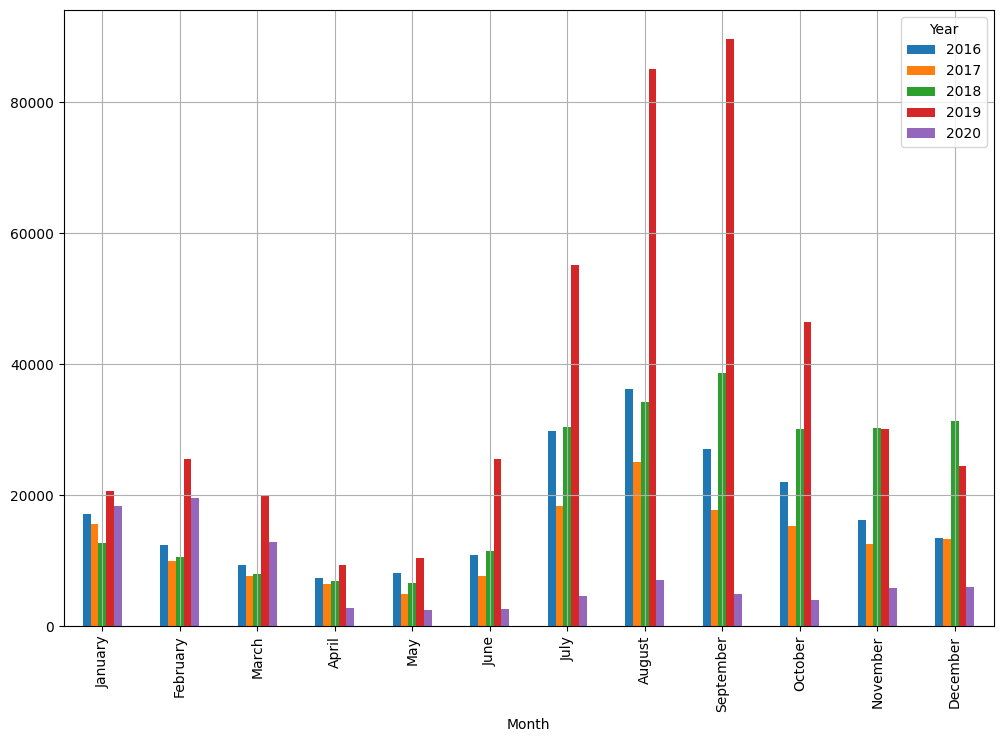

In [13]:

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly_cases = df.groupby(['Month', 'Year'])["Dengue_Cases"].sum()

monthly_cases.unstack().plot(kind='bar')
plt.gcf().set_size_inches(12,8)
plt.grid(True)
plt.xticks(range(0,12), month_order)
plt.show()

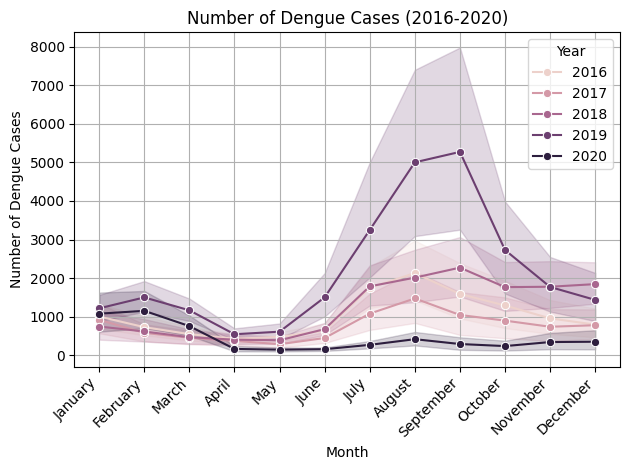

In [14]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Create the line plot
# plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Dengue_Cases', hue='Year', data=df, marker='o')
plt.title('Number of Dengue Cases (2016-2020)')
plt.xlabel('Month')
plt.ylabel('Number of Dengue Cases')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight 1</h1>

<hr></hr>

<h2>In 2016 most cases of dengues increase in months of july to august, but as we compare it to the other years we can see that in year 2016 there is a large numbers of cases. It claims the 3rd position that has the highest amount of denugue cases per months</h2>

<hr></hr>

<h1>Insight 2</h1>

<hr></hr>

<h2>In year 2017 we can conclude that in this year the rate of dengue cases has been dramatically decrease. As we follow the graph above we can see that this year has one of the least cases of dengues.</h2>

<hr></hr>

<h1>Insight 3</h1>

<h2>In the year 2018, there is a rapid increase of dengue cases. Also, this year has the second place in terms of having a highest number of dengue cases.</h2>

<hr></hr>

<h1>Insight 4</h1>

<hr></hr>


<h2>This year has the most large amount of dengue cases. In 2019, there is a rapid growth of dengue cases which goes higher in june to september. we can predict that the colder the weather the more mosquitos are active.</h2>

<h1>Insight 5</h1>

<hr></hr>


<h2>In 2020, this year has the least cases which simplifies that maybe in the year 2019 they created a vaccine for people to take. The pandemic can also be a factor for this due to people taking care of their selves and not going outside.</h2>

<hr></hr>


<h1>Mortality Rate Per Region</h1>

In [6]:
Regional_Death = df.groupby(["Region"])[['Dengue_Deaths', 'Dengue_Cases']].sum().reset_index()
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases
0,BARMM,332,11537
1,CAR,1008,30582
2,NCR,4008,115966
3,Region I,157,59066
4,Region II,193,45141
5,Region III,482,131064
6,Region IV-A,652,163029
7,Region IV-B,130,30849
8,Region IX,532,47781
9,Region V,185,22167


In [7]:
Regional_Death["Mortality_Rate"] = np.round((Regional_Death["Dengue_Deaths"] / Regional_Death["Dengue_Cases"]) * 100,2)
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases,Mortality_Rate
0,BARMM,332,11537,2.88
1,CAR,1008,30582,3.30
2,NCR,4008,115966,3.46
3,Region I,157,59066,0.27
4,Region II,193,45141,0.43
5,Region III,482,131064,0.37
6,Region IV-A,652,163029,0.40
7,Region IV-B,130,30849,0.42
8,Region IX,532,47781,1.11
9,Region V,185,22167,0.83


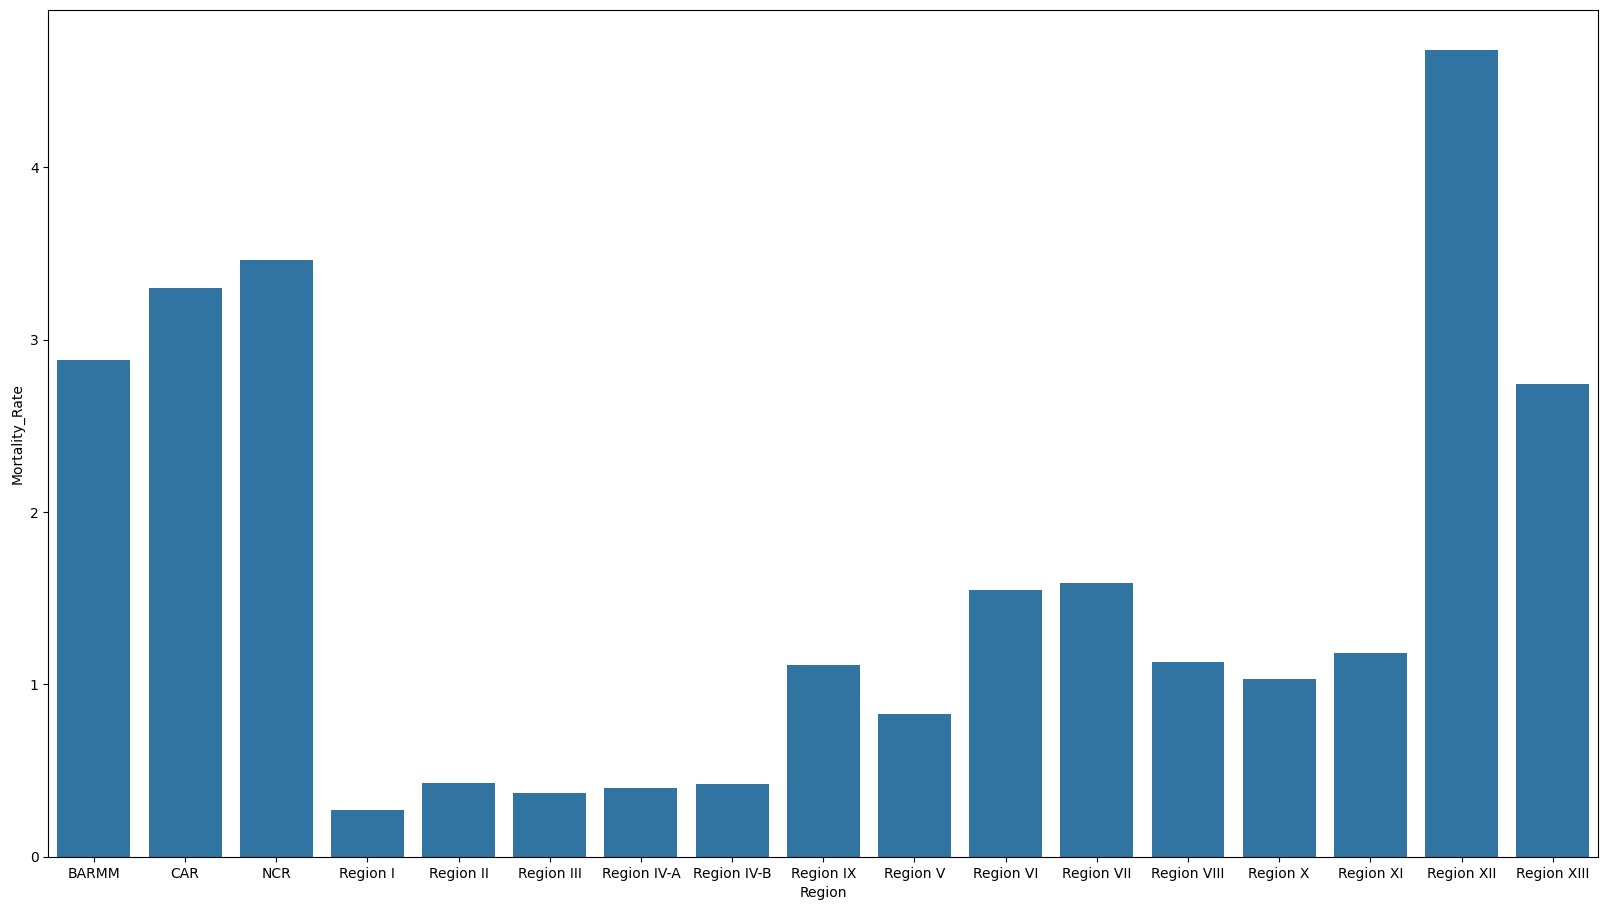

In [8]:
visual2 = sns.barplot(data=Regional_Death, x="Region",y="Mortality_Rate")
plt.gcf().set_size_inches(20,11)
plt.show()

<hr></hr>

<h1>Insight 6</h1>

<h2>Among all regions, Region XII shows a significantly higher mortality rate compared to other regions. This could indicate Limited access to healthcare facilities, Delayed medical intervention, Higher incidence of severe cases.</h2>

<hr></hr>

<h1>Insight 7</h1>

<h2>Regions such as Region I, Region II, Region III, Region IV-A, and Region IV-B show some of the lowest mortality rates. These regions could serve as models for best practices for other areas struggling with higher mortality rates.</h2>

<hr></hr>

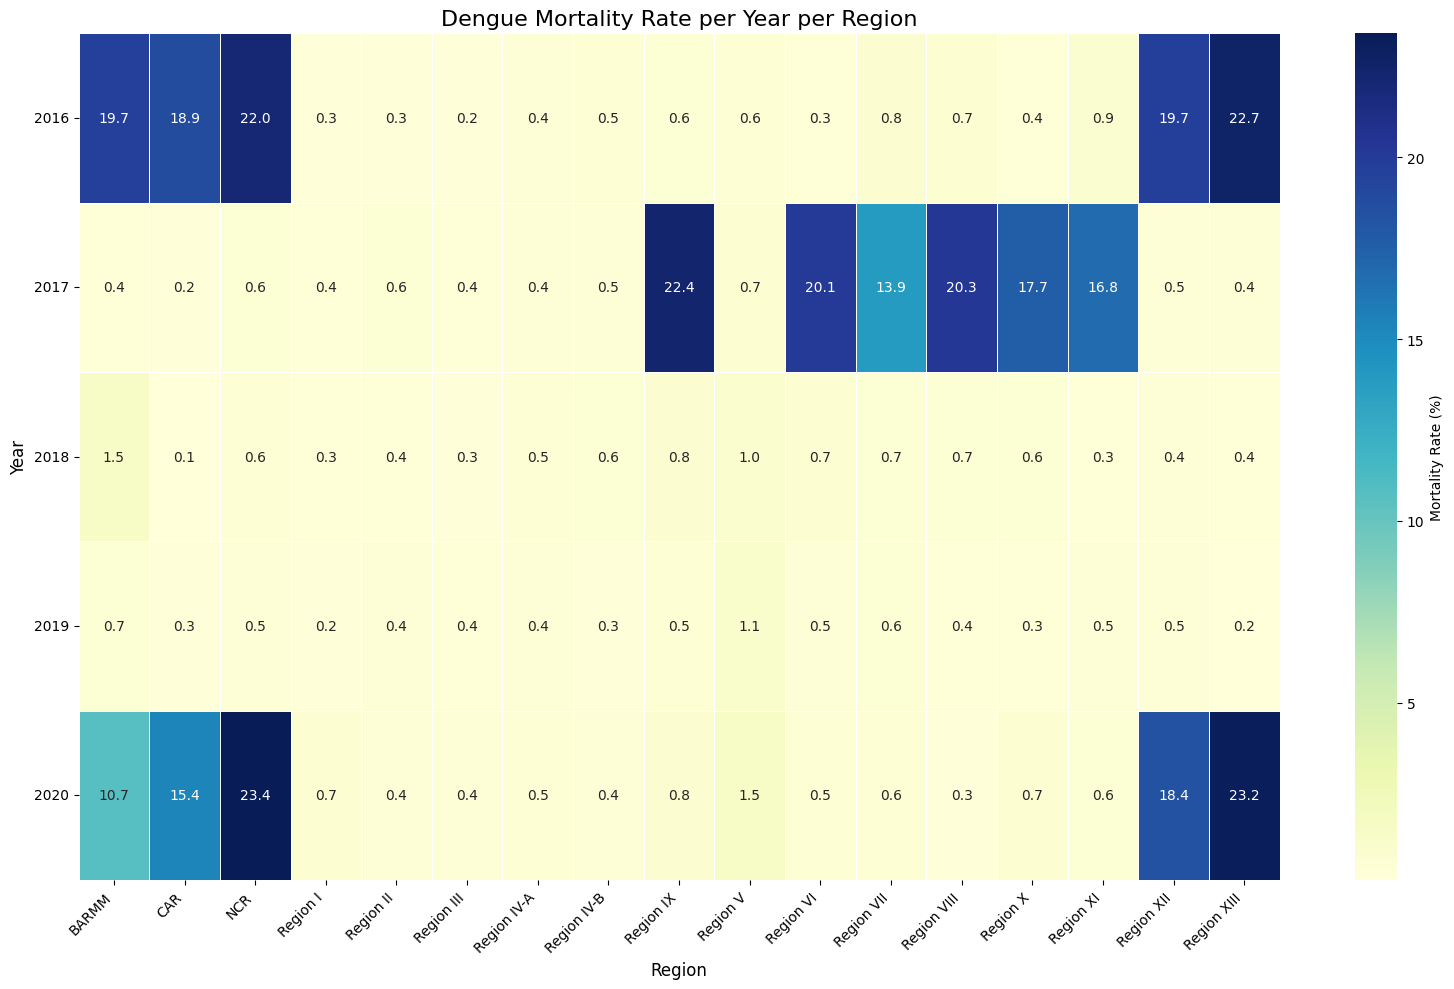

In [12]:

df['Mortality_Rate'] = (df['Dengue_Deaths'] / df['Dengue_Cases']) * 100

# Group by Year and Region and calculate the mean mortality rate
heatmap_data = df.groupby(['Year', 'Region'])['Mortality_Rate'].mean().unstack()

# Create the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Mortality Rate (%)'})
plt.title('Dengue Mortality Rate per Year per Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<hr></hr>

<h1>Insight 8</h1>

<h2>The heatmap shows that some regions faced sudden and severe dengue outbreaks in certain years. For example, NCR and CAR had very high mortality rates in 2016, and Region VIII spiked in 2017. In 2020, NCR and Region XIII again showed alarming numbers. These spikes suggest that dengue hit these areas hard at different times, possibly because of limited medical resources or delayed response during outbreaks.</h2>

<hr></hr>

<h1>Insight 9</h1>

<h2>Most regions managed to keep dengue deaths low from 2016 to 2020. Regions like Region I, II, III, IV-A, and VI consistently had mortality rates below 1%. This suggests good access to treatment, awareness about dengue prevention, and effective response from local health services. These regions may have strong health systems that helped save lives.</h2>

<hr></hr>

<h1>Insight 10</h1>

<h2>There was a worrying increase in dengue deaths in 2020 after two years of improvement. Regions such as NCR, CAR, BARMM, and Region XIII showed sharp rises in mortality. This may have happened because the healthcare system was overwhelmed by COVID-19, making it harder for dengue patients to get timely treatment. It highlights how other diseases can worsen when health services are focused on a major crisis.</h2>

<h1> PREDICTIVES </h1>

In [17]:
df['Month'] = df['Month'].astype('str')

In [19]:
# Combine Month and Year into a Date column
df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))

# Optional: sort by date
df = df.sort_values('Date')

In [21]:
region_df = df[df['Region'] == 'Region IV-A']
monthly_cases = region_df.groupby('Date')['Dengue_Cases'].sum().reset_index()

In [22]:
df

,Month,Year,Region,Dengue_Cases,Dengue_Deaths,Mortality_Rate,Date
0,January,2016,Region I,705,1,0.141844,2016-01-01
840,January,2016,NCR,1261,4,0.317209,2016-01-01
780,January,2016,Region XIII,1116,6,0.537634,2016-01-01
240,January,2016,Region IV-B,203,1,0.492611,2016-01-01
120,January,2016,Region III,1976,3,0.151822,2016-01-01
...,...,...,...,...,...,...,...
119,December,2020,Region II,96,0,0.000000,2020-12-01
899,December,2020,NCR,658,4,0.607903,2020-12-01
59,December,2020,Region I,1081,1,0.092507,2020-12-01
659,December,2020,Region X,281,1,0.355872,2020-12-01


In [23]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Convert dates to ordinal for regression
#monthly_cases['Date_Ordinal'] = monthly_cases['Date'].map(lambda x: x.toordinal())
#other 
monthly_cases['Date_Ordinal'] = monthly_cases['Date'].map(pd.Timestamp.toordinal)

# Reshape for sklearn
X = monthly_cases['Date_Ordinal'].values.reshape(-1, 1) #independent variable 
y = monthly_cases['Dengue_Cases'].values   #dependent variable 

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predict
monthly_cases['Predicted_Cases'] = model.predict(X)

# Evaluate: R-squared
r_squared = model.score(X, y)
print(f"The model explains {r_squared:.1%} of the variation in dengue cases.")

The model explains 1.7% of the variation in dengue cases.


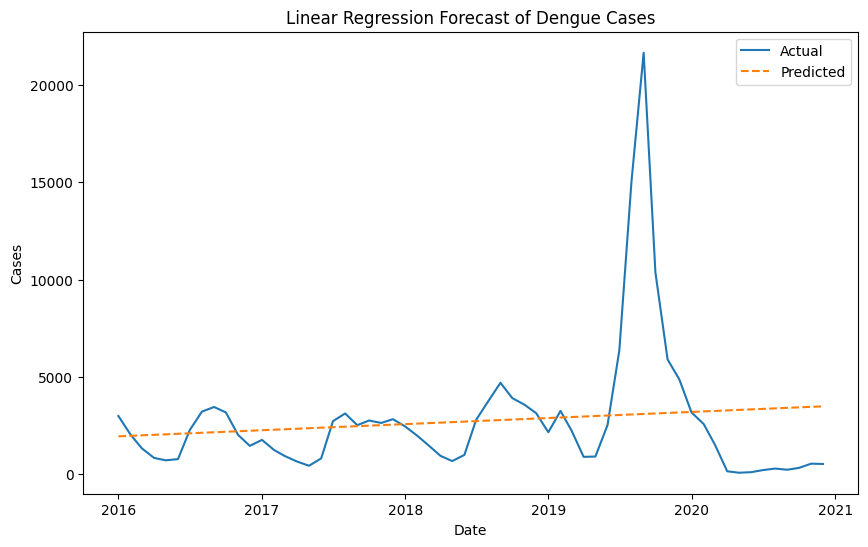

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(monthly_cases['Date'], monthly_cases['Dengue_Cases'], label='Actual')
plt.plot(monthly_cases['Date'], monthly_cases['Predicted_Cases'], label='Predicted', linestyle='--')
plt.legend()
plt.title('Linear Regression Forecast of Dengue Cases')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()